In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('/content/BankChurners.csv')

In [36]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [37]:
df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                         'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],inplace=True)

df.drop(columns='CLIENTNUM',inplace=True)

df['Avg_Transaction_Value'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']

df.drop(columns=['Total_Trans_Amt','Total_Trans_Ct'],inplace=True)

df.drop(columns=['Months_on_book','Total_Revolving_Bal','Avg_Open_To_Buy'],inplace=True)

df['Education_Level'].replace({'Unknown':np.nan,'Post-Graduate':'Advanced_Degree','Doctorate':'Advanced_Degree'},inplace=True)
df['Marital_Status'].replace({'Unknown':np.nan},inplace=True)
df['Income_Category'].replace({'Unknown':np.nan},inplace=True)

/tmp/ipython-input-58012425.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education_Level'].replace({'Unknown':np.nan,'Post-Graduate':'Advanced_Degree','Doctorate':'Advanced_Degree'},inplace=True)
/tmp/ipython-input-58012425.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [38]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Amt_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Transaction_Value
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,5,1,3,12691.0,1.335,1.625,0.061,27.238095
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,6,1,2,8256.0,1.541,3.714,0.105,39.121212
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,4,1,0,3418.0,2.594,2.333,0.000,94.350000
3,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,3,4,1,3313.0,1.405,2.333,0.760,58.550000
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,5,1,0,4716.0,2.175,2.500,0.000,29.142857


In [ ]:
from sklearn import set_config

set_config(transform_output="pandas")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer

In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,:1]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)

In [ ]:
gender_pipe = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encoding',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))
])

education_pipe = Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encoding',OrdinalEncoder(categories=[['Uneducated','High School','College','Graduate','Advanced_Degree']]))
])

marital_income_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False))
])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('gender',gender_pipe,['Gender']),
    ('education',education_pipe,['Education_Level']),
    ('marital_income',marital_income_pipe,['Marital_Status','Income_Category']),
    ('encoding_card',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),['Card_Category']),
    ('power_transform',PowerTransformer(),['Customer_Age','Dependent_count','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon','Credit_Limit','Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Avg_Transaction_Value'])


],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [ ]:
pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score,precision_recall_curve, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

attrition_mapping = {'Existing Customer': 0, 'Attrited Customer': 1}
y_train_enc = y_train['Attrition_Flag'].map(attrition_mapping)
y_test_enc = y_test['Attrition_Flag'].map(attrition_mapping)


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_trans, y_train_enc)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred = lr.predict(X_test_trans)
y_pred_proba = lr.predict_proba(X_test_trans)[:, 1]

Precision: 0.386
Recall: 0.706


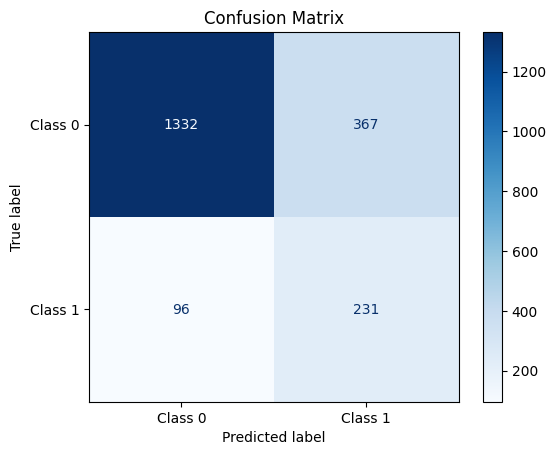

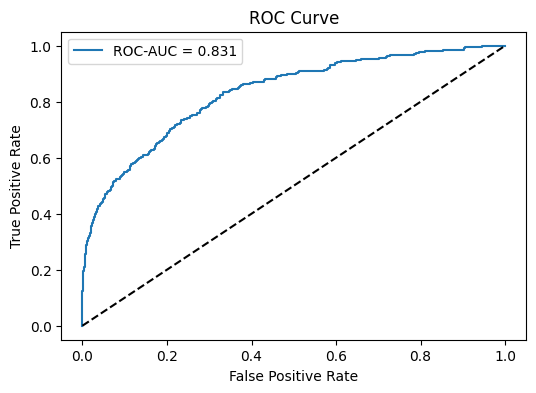

ROC-AUC Score: 0.831051904970184


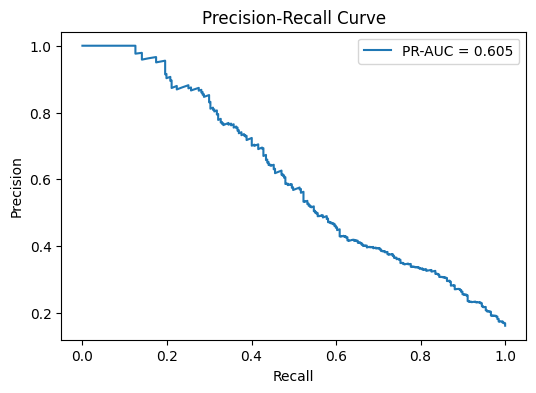

PR-AUC Score: 0.6051614824487889


In [39]:
prec = precision_score(y_test_enc, y_pred)
rec = recall_score(y_test_enc, y_pred)
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

roc_auc = roc_auc_score(y_test_enc, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc)

precision, recall, _ = precision_recall_curve(y_test_enc, y_pred_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()
print("PR-AUC Score:", pr_auc)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
# pip install xgboost

In [ ]:
# pip install lightgbm

In [ ]:
# pip install catboost

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
pip install optuna

In [40]:
import optuna

In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline

In [71]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [82]:
%pip install mlflow dagshub

In [83]:
import dagshub
dagshub.init(repo_owner='Ranjan113', repo_name='credit-card-churn', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=795a15ff-7000-4396-8e08-046c4e7a293d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d391dcad9da1b6b5ee713f649f45300bc8f526b1bf6ca916d399cda865a5cd76




Accessing as Ranjan113

Initialized MLflow to track repo "Ranjan113/credit-card-churn"

Repository Ranjan113/credit-card-churn initialized!

In [84]:
import mlflow

In [85]:
mlflow.set_tracking_uri("https://dagshub.com/Ranjan113/credit-card-churn.mlflow")

In [86]:
mlflow.set_experiment("Exp 3 - Model Selection")

2025/09/06 18:06:15 INFO mlflow.tracking.fluent: Experiment with name 'Exp 3 - Model Selection' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/524d6cff047548a39197a5f423d3d2d8', creation_time=1757181975225, experiment_id='5', last_update_time=1757181975225, lifecycle_stage='active', name='Exp 3 - Model Selection', tags={}>

In [87]:
def objective(trial):
    with mlflow.start_run(nested=True):
        classifier_name = trial.suggest_categorical(
            "classifier", ["SVM", "RandomForest", "GradientBoosting", "xgboost", "lightgbm", "catboost"]
        )

        if classifier_name == "SVM":
            C = trial.suggest_float("C", 0.1, 100, log=True)
            kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"])
            gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
            model = SVC(C=C, kernel=kernel, gamma=gamma, probability=True, random_state=42)

        elif classifier_name == "RandomForest":
            n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
            max_depth = trial.suggest_int("rf_max_depth", 2, 32, log=True)
            model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

        elif classifier_name == "GradientBoosting":
            n_estimators = trial.suggest_int("gb_n_estimators", 50, 300)
            learning_rate = trial.suggest_float("gb_learning_rate", 1e-3, 0.5, log=True)
            max_depth = trial.suggest_int("gb_max_depth", 2, 16)
            model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)

        elif classifier_name == "xgboost":
            n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
            learning_rate = trial.suggest_float("xgb_learning_rate", 1e-3, 0.5, log=True)
            max_depth = trial.suggest_int("xgb_max_depth", 2, 16)
            subsample = trial.suggest_float("xgb_subsample", 0.5, 1.0)
            colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0)
            model = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth,
                                  subsample=subsample, colsample_bytree=colsample_bytree, eval_metric="logloss", random_state=42)

        elif classifier_name == "lightgbm":
            n_estimators = trial.suggest_int("lgbm_n_estimators", 50, 300)
            learning_rate = trial.suggest_float("lgbm_learning_rate", 0.01, 0.2, log=True)
            num_leaves = trial.suggest_int("lgbm_num_leaves", 10, 50)
            min_child_samples = trial.suggest_int("lgbm_min_child_samples", 10, 50)
            reg_alpha = trial.suggest_float("lgbm_reg_alpha", 0, 1.0)
            reg_lambda = trial.suggest_float("lgbm_reg_lambda", 0, 1.0)
            model = LGBMClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                   num_leaves=num_leaves, min_child_samples=min_child_samples,
                                   reg_alpha=reg_alpha, reg_lambda=reg_lambda, random_state=42, verbosity=-1)

        elif classifier_name == "catboost":
            n_estimators = trial.suggest_int("cb_n_estimators", 50, 300)
            learning_rate = trial.suggest_float("cb_learning_rate", 1e-3, 0.5, log=True)
            depth = trial.suggest_int("cb_depth", 2, 10)
            model = CatBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate,
                                       depth=depth, verbose=0, random_state=42)

        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])


        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(pipeline, X_train_trans, y_train_enc, cv=cv, scoring="roc_auc", n_jobs=-1)


        mlflow.log_params(model.get_params())
        mlflow.log_param("model", classifier_name)
        mlflow.log_metric("roc_auc_score", np.mean(scores))

        return np.mean(scores)

In [88]:
study = optuna.create_study(direction='maximize')


with mlflow.start_run(run_name="Best Model") as parent:

    study.optimize(objective,n_trials=50,n_jobs=-1)

    mlflow.log_params(study.best_params)

    mlflow.log_metric("best_score",study.best_value)

[I 2025-09-06 18:18:30,513] A new study created in memory with name: no-name-c32089a2-7d2f-4724-b33e-8dac5549dcdf
[I 2025-09-06 18:18:40,098] Trial 1 finished with value: 0.8624407442750451 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 297, 'rf_max_depth': 2}. Best is trial 1 with value: 0.8624407442750451.


🏃 View run agreeable-gull-906 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/2467447e18d94b70afcb5e2e44dd34ef
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5


[I 2025-09-06 18:19:15,640] Trial 0 finished with value: 0.848350193427366 and parameters: {'classifier': 'GradientBoosting', 'gb_n_estimators': 245, 'gb_learning_rate': 0.0011867007860328286, 'gb_max_depth': 4}. Best is trial 1 with value: 0.8624407442750451.


🏃 View run secretive-sloth-603 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/9440b765ade44d0aab0fc11ed0f6d6e5
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5
🏃 View run magnificent-carp-857 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/b3ce8a86b5034c40baa74504db94a3e1
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5


[I 2025-09-06 18:19:52,090] Trial 2 finished with value: 0.8592813180125395 and parameters: {'classifier': 'SVM', 'C': 10.129702864105825, 'kernel': 'poly', 'gamma': 'scale'}. Best is trial 1 with value: 0.8624407442750451.


...

🏃 View run handsome-grouse-146 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/9de655fc037a414093e9b4f08617b2d2
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5
🏃 View run bittersweet-wasp-737 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/d46be1e36eee492ca07e92908dc42758
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5


[I 2025-09-06 18:31:13,776] Trial 48 finished with value: 0.9081717160771109 and parameters: {'classifier': 'xgboost', 'xgb_n_estimators': 220, 'xgb_learning_rate': 0.02992392946903063, 'xgb_max_depth': 4, 'xgb_subsample': 0.9382406048828852, 'xgb_colsample_bytree': 0.5904206775280414}. Best is trial 42 with value: 0.9245613696251146.


🏃 View run sedate-snipe-742 at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/d3d29288da154453a56b9532330f069c
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5


[I 2025-09-06 18:31:19,757] Trial 49 finished with value: 0.9089102368273531 and parameters: {'classifier': 'xgboost', 'xgb_n_estimators': 222, 'xgb_learning_rate': 0.03115585824932454, 'xgb_max_depth': 4, 'xgb_subsample': 0.9257314145592521, 'xgb_colsample_bytree': 0.5877641239193567}. Best is trial 42 with value: 0.9245613696251146.


🏃 View run Best Model at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5/runs/215709f976234f28b92b184ffd984d36
🧪 View experiment at: https://dagshub.com/Ranjan113/credit-card-churn.mlflow/#/experiments/5


In [89]:
plot_optimization_history(study).show()

In [90]:
optuna.visualization.plot_parallel_coordinate(study,params=["classifier"])

In [91]:
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'xgboost', 'xgb_n_estimators': 261, 'xgb_learning_rate': 0.05234950446452074, 'xgb_max_depth': 7, 'xgb_subsample': 0.9998532598274361, 'xgb_colsample_bytree': 0.570870702664962}
Best trial accuracy: 0.9245613696251146


In [92]:
study.trials_dataframe()['params_classifier'].value_counts()

,count
params_classifier,
xgboost,26
GradientBoosting,6
RandomForest,5
SVM,5
lightgbm,5
catboost,3


In [99]:
study.trials_dataframe().groupby('params_classifier')['value'].mean().sort_values(ascending=False)

,value
params_classifier,
xgboost,0.914924
lightgbm,0.909923
catboost,0.888973
RandomForest,0.885438
GradientBoosting,0.868909
SVM,0.860063


In [104]:
study.best_params

{'classifier': 'xgboost',
 'xgb_n_estimators': 261,
 'xgb_learning_rate': 0.05234950446452074,
 'xgb_max_depth': 7,
 'xgb_subsample': 0.9998532598274361,
 'xgb_colsample_bytree': 0.570870702664962}

In [105]:
xgb_params = {
  'n_estimators': 261,
  'learning_rate': 0.05234950446452074,
  'max_depth': 7,
  'subsample': 0.9998532598274361,
  'colsample_bytree': 0.570870702664962
}

In [106]:

final_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(**xgb_params))
])

final_pipeline.fit(X_train_trans, y_train_enc)
y_pred = final_pipeline.predict(X_test_trans)
y_pred_proba = final_pipeline.predict_proba(X_test_trans)[:, 1]


Precision: 0.764
Recall: 0.624


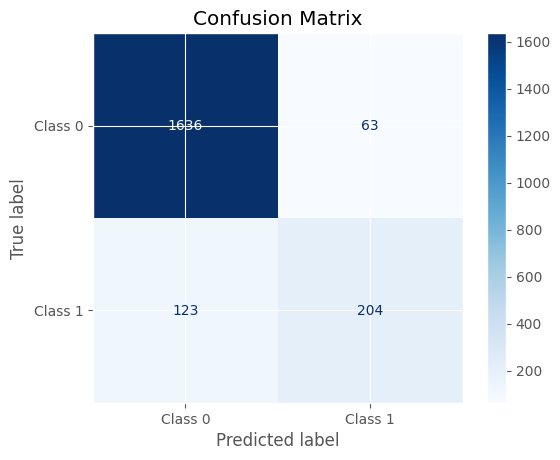

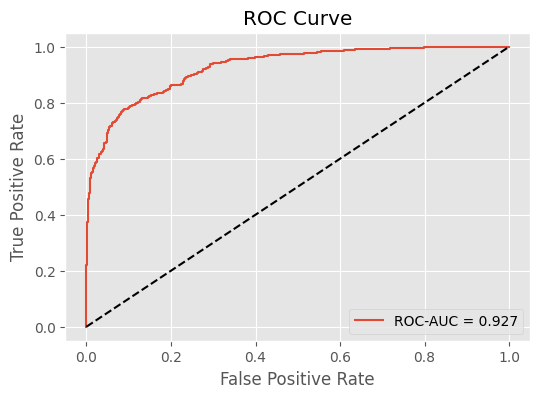

ROC-AUC Score: 0.9265299069609215


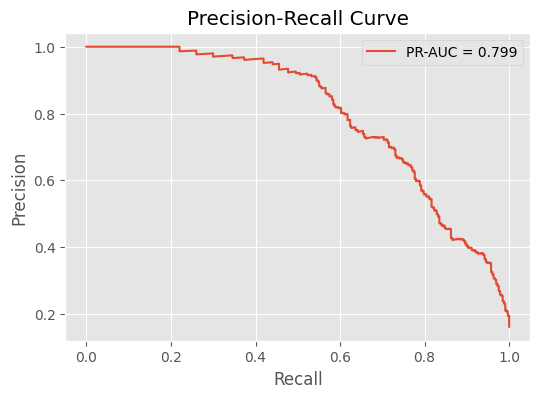

PR-AUC Score: 0.7985530675698642


In [110]:
prec = precision_score(y_test_enc, y_pred)
rec = recall_score(y_test_enc, y_pred)
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")


cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


roc_auc = roc_auc_score(y_test_enc, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test_enc, y_pred_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc)


precision, recall, _ = precision_recall_curve(y_test_enc, y_pred_proba)
pr_auc = auc(recall, precision)
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()
print("PR-AUC Score:", pr_auc)

In [ ]:
# Note: Training XGB on the full resampled dataset (X_train_res) means the model sees all synthetic points at once.
# During Optuna hyperparameter tuning, SMOTE was applied within each CV fold (only ~2/3 of data seen per fold),
# so the optimized results were based on that limited view. Training on the full resampled data may give slightly
# optimistic or misleading performance metrics compared to the CV-based evaluation.


In [ ]:
# but why we did smoting inside optuna and not before?

# What happens:

# SMOTE creates synthetic samples from ALL your training data
# During cross-validation, some of these synthetic samples end up in training folds
# Some synthetic samples end up in validation folds
# Problem: Validation folds contain synthetic data that was created FROM the training data
# This creates data leakage - the model has indirect access to validation data during training